# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Métodos Predictivos**
### Cátedra: Bianco
#### **Regresión Lineal Simple**

# Ejercicios práctico con Datos

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

os.chdir(os.path.dirname(__vsc_ipynb_file__))


In [2]:
# Obtenemos los datos del archivo
df = pd.read_csv("RLS-income.data.csv", index_col=0)
df.head()

,income,happiness
1,3.862647,2.314489
2,4.979381,3.433490
3,4.923957,4.599373
4,3.214372,2.791114
5,7.196409,5.596398


Se busca determinar si la felicidad de una persona puede estar relacionada con el ingreso.

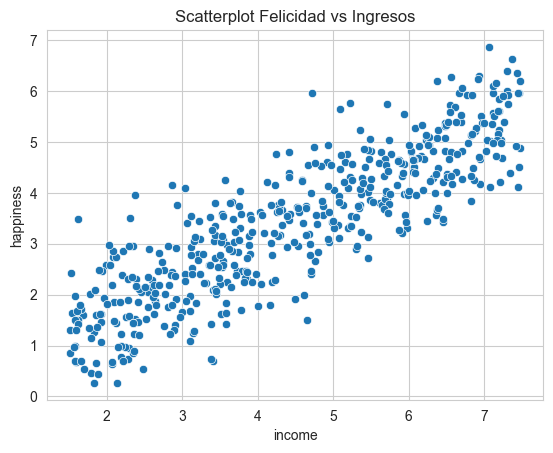

In [3]:
# Graficamos la dispersión de los datos
sns.set_style("whitegrid")

plt.figure()

sns.scatterplot(data=df, x="income", y="happiness")

plt.title("Scatterplot Felicidad vs Ingresos")
plt.xlabel("income")
plt.ylabel("happiness")

plt.show()

Se observa una relación positiva entre ingreso y felicidad. A mayor ingreso, mayor felicidad.

Ahora vamos a proceder a calcular la recta que mejor ajusta a nuestro conjunto de datos que buscan evaluar la felicidad en función del ingreso:

In [4]:
# Ajuste del modelo
ajuste = smf.ols(formula="happiness ~ income", data=df).fit()

# Ver el modelo (resumen completo tipo R)
print(ajuste.summary())

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     1483.
Date:                Sat, 30 May 2026   Prob (F-statistic):          3.96e-151
Time:                        23:49:58   Log-Likelihood:                -540.72
No. Observations:                 498   AIC:                             1085.
Df Residuals:                     496   BIC:                             1094.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2043      0.089      2.299      0.0

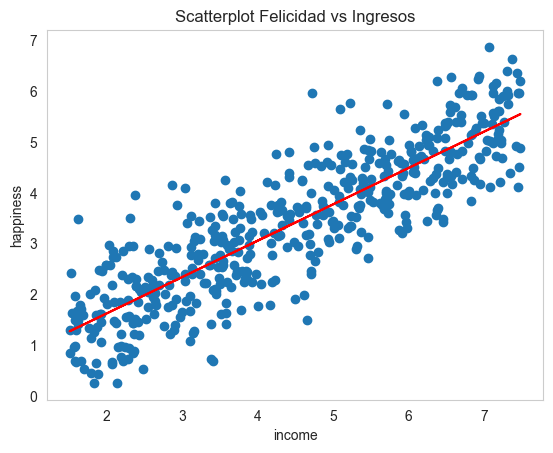

In [5]:
plt.figure()

# Puntos reales
plt.scatter(df["income"], df["happiness"])

# Recta del modelo ya estimado
y_pred = ajuste.predict(df)
plt.plot(df["income"], y_pred, color="red")

plt.title("Scatterplot Felicidad vs Ingresos")
plt.xlabel("income")
plt.ylabel("happiness")

plt.grid()
plt.show()

## Modelo Global

### $R^2$ y $R^2_{ajustado}$

En este modelo se observa: $R^2 = 0.749$

Esto implica que el $74.9\%$ de la variabilidad de la felicidad es explicada por el ingreso.

El $R^2$ ajustado corrige esta medida penalizando la inclusión de variables irrelevantes: $R^2_{ajustado} = 0.749$.

- $R^2$ siempre aumenta (o se mantiene) al agregar variables.
- $R^2_{ajustado}$ solo aumenta si las nuevas variables aportan información relevante.

En este caso, ambos coinciden porque el modelo tiene una única variable explicativa.

El estadístico F evalúa si el modelo en su conjunto tiene capacidad explicativa.

$F = 1483$

Su hipótesis es:

- $H_0$: el modelo no explica la variable dependiente (coeficientes $= 0$)
- $H_1$: el modelo tiene capacidad explicativa

El p-valor asociado es:
$p\text{-valor} = 3.96 \times 10^{-151}$

Dado que el p-valor es extremadamente bajo, se rechaza $H_0$.

**Conclusión:** el modelo es globalmente significativo, es decir, el ingreso explica de manera estadísticamente significativa la felicidad.

### Grados de libertad y estructura del modelo

El modelo presenta:

- Número de observaciones: $n = 498$
- Grados de libertad del modelo: $df_{modelo} = 1$
- Grados de libertad de los residuos: $df_{residual} = 496$

Relación:
$$df_{residual} = n - k - 1$$

donde:
- $n$ = número de observaciones
- $k$ = número de variables explicativas

En este caso:
$$496 = 498 - 1 - 1$$

Esto refleja que se estiman dos parámetros: ordenada al origen y pendiente.

### Parámetros $\beta_0$ y $\beta_1$

El modelo estimado es:
$$\hat{happiness} = 0.2043 + 0.7138 \cdot income$$

- **Intercepto** ($\beta_0 = 0.2043$): representa el nivel esperado de felicidad cuando el ingreso es cero. En términos prácticos, suele tener poca interpretación económica directa, pero es necesario para ajustar correctamente la recta.
- **Pendiente** ($\beta_1 = 0.7138$): indica que, en promedio, un incremento de una unidad en el ingreso está asociado con un aumento de $0.7138$ unidades en la felicidad.

El estadístico t evalúa si cada coeficiente es significativamente distinto de cero:
$$t = \frac{\hat{\beta}}{SE(\hat{\beta})}$$

Resultados:
- Intercepto: $t = 2.299$
- income: $t = 38.505$

Valores altos en valor absoluto indican mayor evidencia contra la hipótesis nula ($\beta = 0$).

El p-valor mide la probabilidad de observar un estadístico $t$ tan extremo si el coeficiente fuera cero:
- Intercepto: $p = 0.022$
- income: $p \approx 0.000$

**Conclusión:** ambos coeficientes son estadísticamente significativos al 5%. Especialmente el ingreso, con evidencia extremadamente fuerte.

#### Intervalos de Confianza
- Intercepto: $[0.030,\ 0.379]$
- income: $[0.677,\ 0.750]$

**Interpretación:** el intervalo contiene los valores plausibles del parámetro poblacional con un 95% de confianza.

> ¿Qué pasa si el intervalo incluye el 0? Si el IC incluye el 0, entonces no se puede descartar que el coeficiente sea igual a cero — la variable no sería estadísticamente significativa. En este modelo ningún intervalo incluye el 0, por lo tanto ambos coeficientes son significativos.

## Diagnóstico del modelo a partir de los residuos

Esta sección evalúa si los supuestos del modelo lineal se cumplen, analizando los residuos.

### Normalidad de los residuos (Jarque-Bera y Omnibus)

Se reportan dos tests:
- **Omnibus**: test global de normalidad
- **Jarque-Bera (JB)**: basado en asimetría y curtosis

$$H_0: \text{los residuos no siguen una distribución normal}$$
$$H_1: \text{los residuos siguen una distribución normal}$$

Interpretación del p-valor:
- $p > 0.05$ → no se rechaza $H_0$ → residuos normales
- $p \leq 0.05$ → se rechaza $H_0$ → residuos no normales

Con los resultados $Prob(Omnibus) = 0.498$ y $Prob(JB) = 0.509$:

**Interpretación:** como los p-valores son altos ($> 0.05$), no se rechaza la normalidad.

### Asimetría y curtosis

- $Skew = 0.127$ → distribución aproximadamente simétrica
- $Kurtosis = 2.995$ → muy cercana a 3 (normal)

**Conclusión:** los residuos se comportan de forma muy cercana a una normal.

### Autocorrelación (Durbin-Watson)

$DW = 1.877$

- Valores cercanos a 2 → ausencia de autocorrelación
- Valores cercanos a 0 → autocorrelación positiva
- Valores cercanos a 4 → autocorrelación negativa

Con este valor no hay evidencia de autocorrelación en los residuos.

### Número de condición

$Cond.\ No. = 13.7$ mide problemas de multicolinealidad o inestabilidad numérica. Valores bajos (como este) indican que no hay problemas relevantes.

### Conclusión general

Los residuos cumplen razonablemente los supuestos del modelo lineal, lo que respalda la validez de las inferencias realizadas.

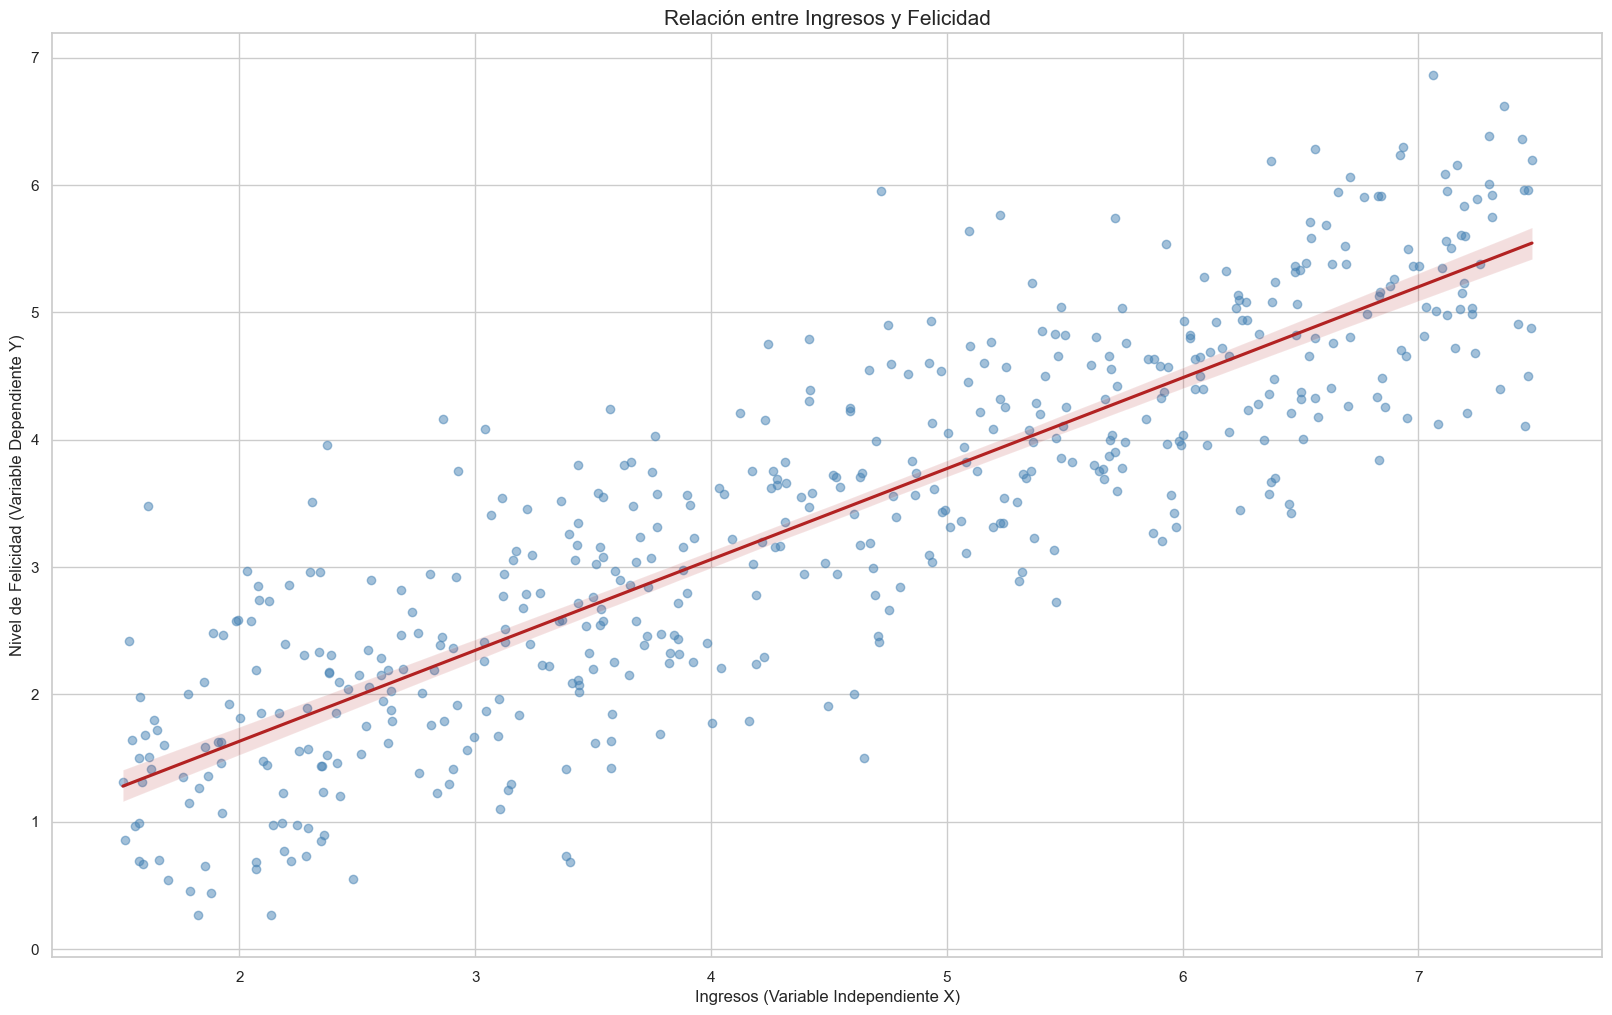

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 12))

sns.regplot(x="income", y="happiness", data=df,
            scatter_kws={"alpha": 0.5, "color": "steelblue"},
            line_kws={"color": "firebrick"})

plt.title("Relación entre Ingresos y Felicidad", fontsize=15)
plt.xlabel("Ingresos (Variable Independiente X)", fontsize=12)
plt.ylabel("Nivel de Felicidad (Variable Dependiente Y)", fontsize=12)

plt.show()

El `regplot` dibuja:
- El scatter plot (puntos reales)
- La recta de regresión (ajuste OLS)
- El intervalo de confianza del 95% (sombra translúcida)

## Intervalo de Confianza de la Media vs Intervalo de Predicción

A la hora de hacer inferencia con el modelo, hay que distinguir dos tipos de intervalos:

| Intervalo | ¿Qué estima? | ¿Qué tan ancho es? |
|---|---|---|
| **IC de la Media** | La posición promedio de la recta | Más estrecho |
| **IC de Predicción** | El valor individual de un nuevo dato | Más ancho |

El IC de predicción es siempre más amplio porque incorpora tanto la incertidumbre sobre la media como la variabilidad natural de los datos individuales.

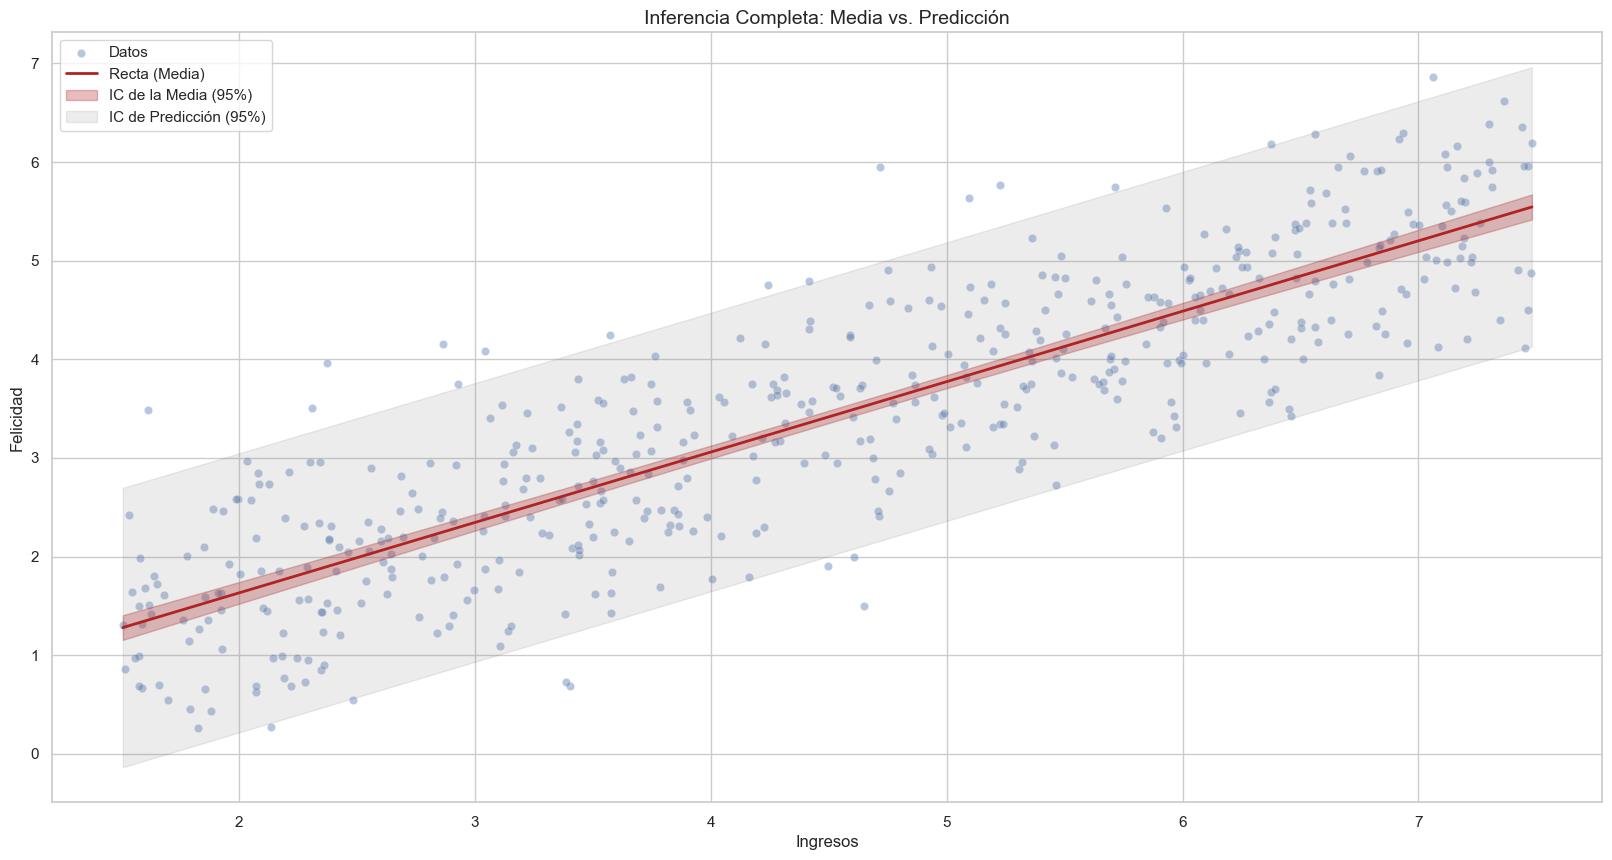

In [7]:
# Creamos un rango de valores de income para graficar los intervalos
x_pred = pd.DataFrame({
    "income": np.linspace(df["income"].min(), df["income"].max(), 300)
})

# Calculamos ambos intervalos usando el objeto 'ajuste'
# Para un 95% (alpha=0.05) de confianza
pred_summary = ajuste.get_prediction(x_pred).summary_frame(alpha=0.05)

plt.figure(figsize=(20, 10))

# Puntos reales
sns.scatterplot(x="income", y="happiness", data=df, alpha=0.4, label="Datos")

# Recta de regresión (la media estimada)
plt.plot(x_pred["income"], pred_summary["mean"], color="firebrick", lw=2, label="Recta (Media)")

# INTERVALO DE LA MEDIA (Confianza de la regresión)
# Mide qué tan seguros estamos de la posición de la recta
plt.fill_between(x_pred["income"],
                 pred_summary["mean_ci_lower"],
                 pred_summary["mean_ci_upper"],
                 color="firebrick", alpha=0.3, label="IC de la Media (95%)")

# INTERVALO DE PREDICCIÓN (individuos)
# Mide la dispersión esperada de datos reales individuales
plt.fill_between(x_pred["income"],
                 pred_summary["obs_ci_lower"],
                 pred_summary["obs_ci_upper"],
                 color="gray", alpha=0.15, label="IC de Predicción (95%)")

plt.title("Inferencia Completa: Media vs. Predicción", fontsize=14)
plt.xlabel("Ingresos", fontsize=12)
plt.ylabel("Felicidad", fontsize=12)
plt.legend()
plt.show()

## Predicción puntual

Una vez ajustado el modelo, podemos predecir el nivel esperado de felicidad para un valor específico de ingreso.

Por ejemplo, para una persona con `income = 5`:

In [8]:
# Predicción para un valor puntual de income
nuevo_valor = pd.DataFrame({"income": [5]})

pred = ajuste.get_prediction(nuevo_valor).summary_frame(alpha=0.05)
pred.index = ["income = 5"]
pred[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]]

,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
income = 5,3.773398,3.70726,3.839536,2.360955,5.185841


In [9]:
# Interpretación de los resultados
media_pred = pred["mean"].values[0]
ic_media_low = pred["mean_ci_lower"].values[0]
ic_media_up  = pred["mean_ci_upper"].values[0]
ic_pred_low  = pred["obs_ci_lower"].values[0]
ic_pred_up   = pred["obs_ci_upper"].values[0]

print(f"Para income = 5:")
print(f"  Felicidad media estimada  : {media_pred:.4f}")
print(f"  IC de la media (95%)      : [{ic_media_low:.4f}, {ic_media_up:.4f}]")
print(f"  IC de predicción (95%)    : [{ic_pred_low:.4f}, {ic_pred_up:.4f}]")

Para income = 5:
  Felicidad media estimada  : 3.7734
  IC de la media (95%)      : [3.7073, 3.8395]
  IC de predicción (95%)    : [2.3610, 5.1858]


## Diagnóstico visual de los residuos

Para verificar los supuestos del modelo lineal, se grafica:

1. **Residuos vs. valores ajustados** — detecta heterocedasticidad y no linealidad
2. **Q-Q plot** — evalúa normalidad de los residuos
3. **Histograma de residuos** — distribución de los errores
4. **Residuos vs. variable independiente** — detecta patrones no capturados por el modelo

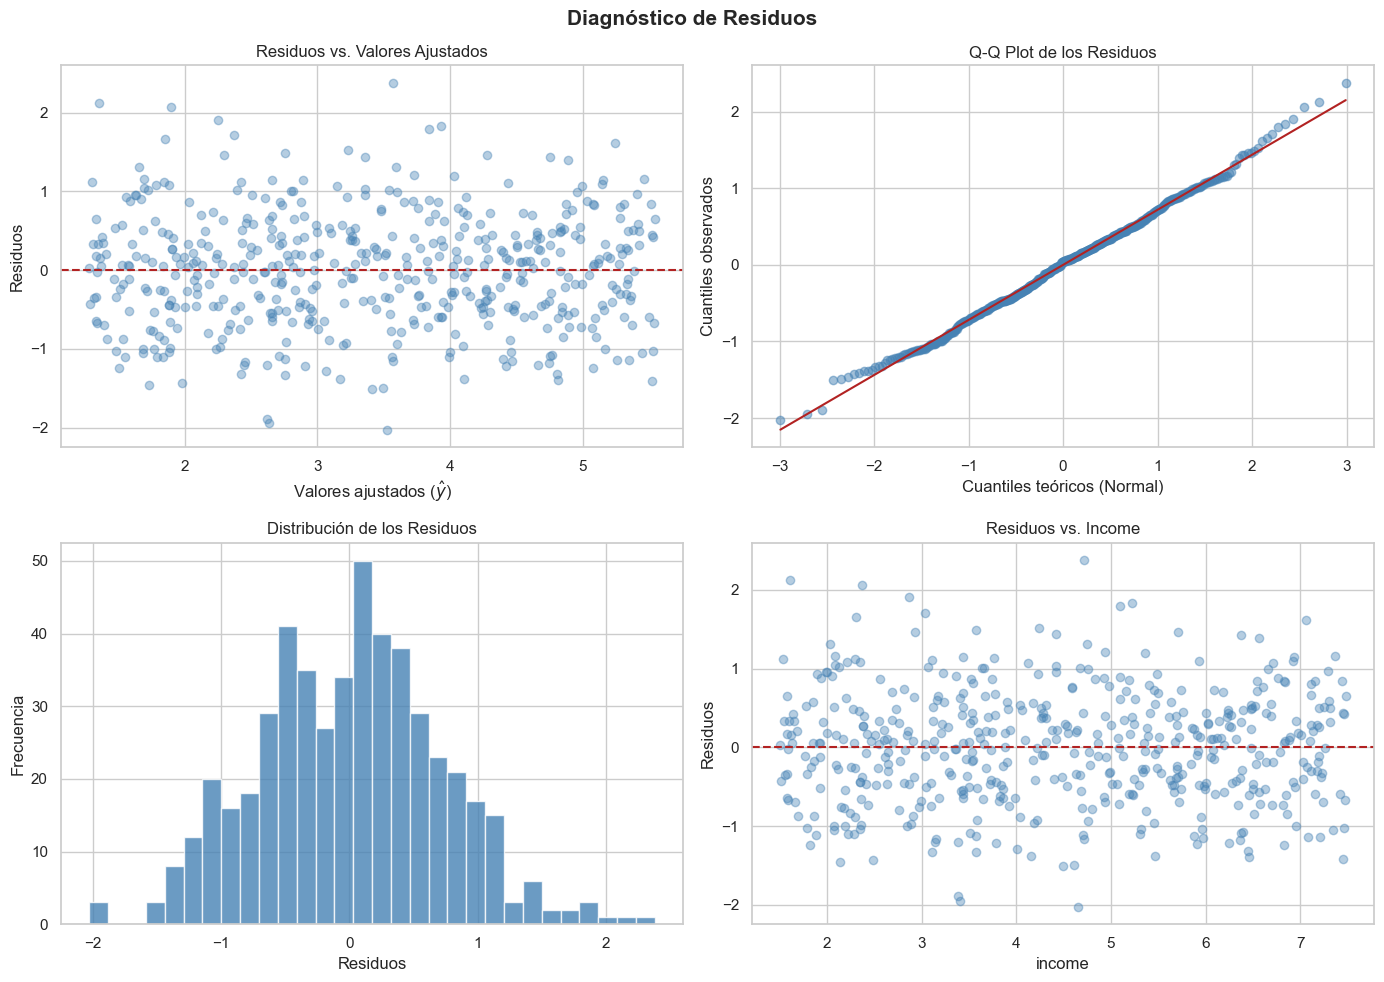

In [10]:
from scipy import stats as scipy_stats

residuos        = ajuste.resid
valores_ajustados = ajuste.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Diagnóstico de Residuos", fontsize=15, fontweight="bold")

# 1. Residuos vs. Valores ajustados
axes[0, 0].scatter(valores_ajustados, residuos, alpha=0.4, color="steelblue")
axes[0, 0].axhline(0, color="firebrick", linestyle="--", lw=1.5)
axes[0, 0].set_title("Residuos vs. Valores Ajustados")
axes[0, 0].set_xlabel("Valores ajustados ($\\hat{y}$)")
axes[0, 0].set_ylabel("Residuos")

# 2. Q-Q plot de normalidad
(osm, osr), (slope, intercept, _) = scipy_stats.probplot(residuos, dist="norm")
axes[0, 1].scatter(osm, osr, alpha=0.5, color="steelblue")
axes[0, 1].plot(osm, slope * np.array(osm) + intercept, color="firebrick", lw=1.5)
axes[0, 1].set_title("Q-Q Plot de los Residuos")
axes[0, 1].set_xlabel("Cuantiles teóricos (Normal)")
axes[0, 1].set_ylabel("Cuantiles observados")

# 3. Histograma de residuos
axes[1, 0].hist(residuos, bins=30, edgecolor="white", color="steelblue", alpha=0.8)
axes[1, 0].set_title("Distribución de los Residuos")
axes[1, 0].set_xlabel("Residuos")
axes[1, 0].set_ylabel("Frecuencia")

# 4. Residuos vs. Variable independiente (income)
axes[1, 1].scatter(df["income"], residuos, alpha=0.4, color="steelblue")
axes[1, 1].axhline(0, color="firebrick", linestyle="--", lw=1.5)
axes[1, 1].set_title("Residuos vs. Income")
axes[1, 1].set_xlabel("income")
axes[1, 1].set_ylabel("Residuos")

plt.tight_layout()
plt.show()

### Interpretación del diagnóstico visual

| Gráfico | Qué se busca | Resultado |
|---|---|---|
| Residuos vs. Ajustados | Dispersión homogénea (homocedasticidad) | Sin patrón sistemático ✓ |
| Q-Q Plot | Puntos sobre la diagonal → normalidad | Ajuste cercano a la diagonal ✓ |
| Histograma | Forma de campana simétrica | Distribución aproximadamente normal ✓ |
| Residuos vs. Income | Sin estructura → modelo bien especificado | Sin patrón sistemático ✓ |

Los cuatro gráficos son consistentes con el diagnóstico numérico del `summary()`: **los supuestos del modelo lineal se cumplen razonablemente**.

## Resumen del modelo

| Componente | Valor | Interpretación |
|---|---|---|
| $R^2$ | 0.749 | El 74.9% de la variabilidad de la felicidad es explicada por el ingreso |
| F-statistic | 1483 | El modelo es globalmente significativo ($p \approx 0$) |
| $\beta_0$ | 0.2043 | Felicidad esperada cuando income = 0 |
| $\beta_1$ | 0.7138 | Por cada unidad adicional de ingreso, la felicidad aumenta 0.7138 unidades |
| Durbin-Watson | 1.877 | No hay autocorrelación en los residuos |
| Jarque-Bera $p$ | 0.509 | No se rechaza normalidad de residuos |

**Ecuación del modelo:**
$$\hat{happiness} = 0.2043 + 0.7138 \cdot income$$